In [1]:
"""
Fraud Detection Dataset - Exploratory Data Analysis (EDA)
==========================================================
A comprehensive exploratory data analysis of the fraud detection dataset to understand 
data structure, quality, distributions, and feature relationships.

Author: Data Analysis Team
Date: 2026
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
plt.style.use('ggplot')
sns.set_palette("husl")

# Configure data directory
data_dir = Path('../data')

In [2]:
"""
Load and merge transaction and identity datasets
"""
try:
    train_transaction = pd.read_csv(data_dir / 'test_transaction.csv')
    train_identity = pd.read_csv(data_dir / 'test_identity.csv')
    df = train_transaction.merge(train_identity, on='TransactionID', how='left')
    print(f"✓ Successfully loaded transaction and identity data")
except FileNotFoundError as e:
    print(f"✗ Error: {e}")
    df = None

✓ Successfully loaded transaction and identity data


In [3]:
"""
Display merged dataset dimensions
"""
if df is not None:
    dataset_info = {
        'Total Records': df.shape[0],
        'Total Features': df.shape[1]
    }
    pd.Series(dataset_info)

## Data Loading & Overview

Understanding the structure and dimensionality of the merged transaction and identity datasets.

In [4]:
"""
Display comprehensive data structure and information
"""
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 506691 entries, 0 to 506690
Columns: 433 entries, TransactionID to DeviceInfo
dtypes: float64(399), int64(3), str(31)
memory usage: 1.6 GB


## Data Quality Assessment

### Missing Values Analysis
Identifying and quantifying missing data across all features to inform data preprocessing strategies.

In [5]:
"""
Quantify and analyze missing data patterns across features
"""
missing = df.isnull().mean().sort_values(ascending=False)

missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing %': (missing.values * 100).round(2),
    'Missing Count': (missing.values * len(df)).astype(int)
})

display(missing_df[missing_df['Missing %'] > 0].head(25))

,Column,Missing %,Missing Count
0,id-24,99.06,501951
1,id-25,99.01,501652
2,id-26,99.00,501644
3,id-07,99.00,501632
4,id-08,99.00,501632
5,id-21,99.00,501632
6,id-22,99.00,501629
7,id-27,99.00,501629
8,id-23,99.00,501629
9,dist2,92.81,470255


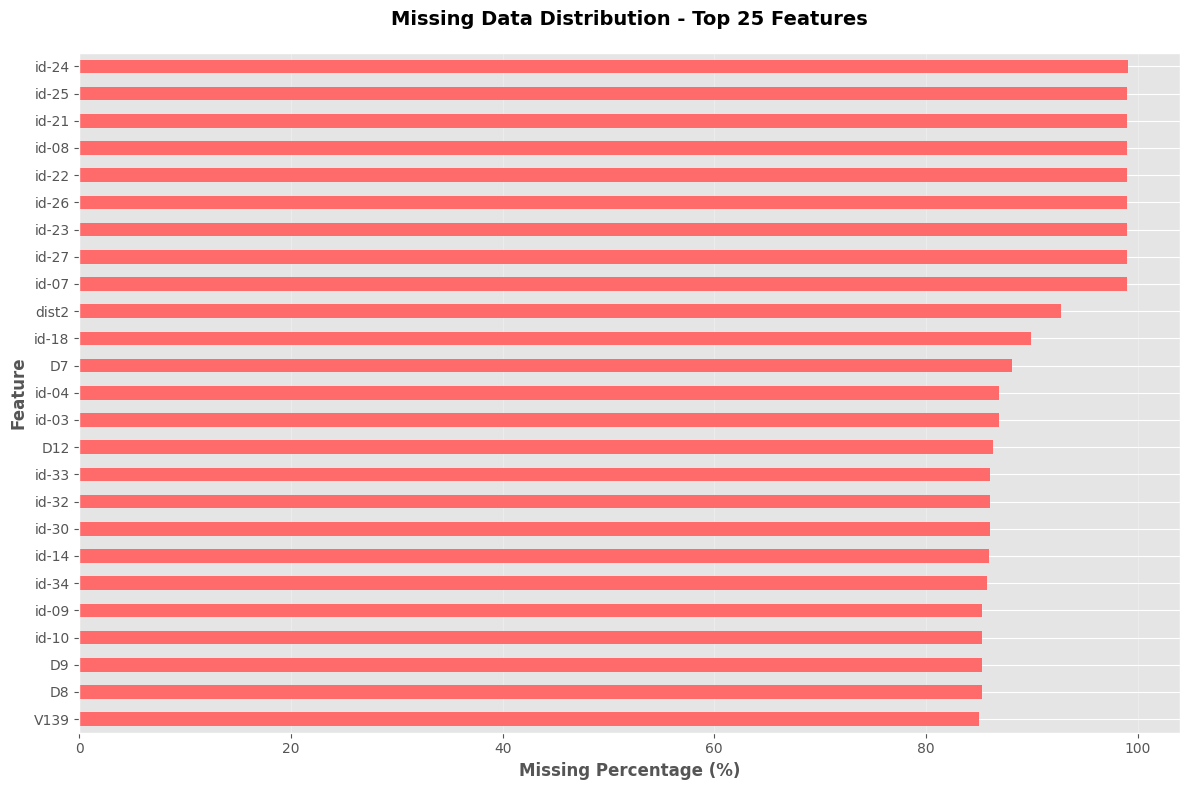

In [6]:
"""
Visualize missing data distribution across top features
"""
fig, ax = plt.subplots(figsize=(12, 8))
missing_plot_data = missing_df[missing_df['Missing %'] > 0].head(25).sort_values('Missing %')
missing_plot_data.plot(x='Column', y='Missing %', kind='barh', ax=ax, color='#FF6B6B', legend=False)
ax.set_title('Missing Data Distribution - Top 25 Features', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Missing Percentage (%)', fontsize=12, fontweight='bold')
ax.set_ylabel('Feature', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Univariate Analysis

### Numerical Features Overview
Statistical characterization of numeric features including central tendency, dispersion, and distribution shape.

In [7]:
"""
Categorize and count feature types in the dataset
"""
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

feature_summary = {
    'Numerical Features': len(numeric_cols),
    'Categorical Features': len(categorical_cols),
    'Total Features': len(df.columns)
}

feature_summary_series = pd.Series(feature_summary)
display(feature_summary_series)

Numerical Features      402
Categorical Features     31
Total Features          433
dtype: int64

In [8]:
"""
Generate comprehensive descriptive statistical summary
"""
descriptive_stats = df.describe(include='all').T
display(descriptive_stats)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
TransactionID,506691.0,NaN,NaN,NaN,3916894.0,146269.23696,3663549.0,3790221.5,3916894.0,4043566.5,4170239.0
TransactionDT,506691.0,NaN,NaN,NaN,26929937.228952,4756506.709752,18403224.0,22771540.5,27204658.0,31348560.5,34214345.0
TransactionAmt,506691.0,NaN,NaN,NaN,134.725568,245.779822,0.018,40.0,67.95,125.0,10270.0
ProductCD,506691,5,W,360987,NaN,NaN,NaN,NaN,NaN,NaN,NaN
card1,506691.0,NaN,NaN,NaN,9957.222175,4884.960969,1001.0,6019.0,9803.0,14276.0,18397.0
...,...,...,...,...,...,...,...,...,...,...,...
id-36,136977,2,F,133287,NaN,NaN,NaN,NaN,NaN,NaN,NaN
id-37,136977,2,T,104697,NaN,NaN,NaN,NaN,NaN,NaN,NaN
id-38,136977,2,F,95058,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DeviceType,136931,2,desktop,74403,NaN,NaN,NaN,NaN,NaN,NaN,NaN


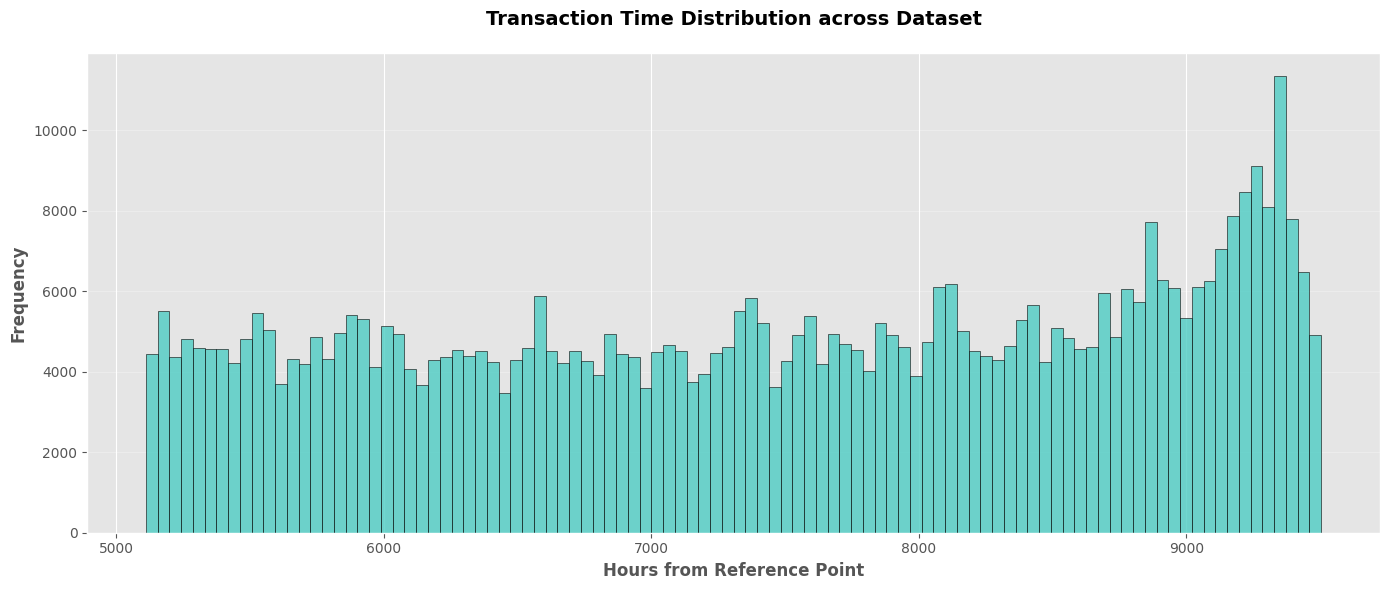

In [9]:
"""
Analyze temporal distribution of transactions
"""
df['TransactionDT_hours'] = df['TransactionDT'] / 3600

fig, ax = plt.subplots(figsize=(14, 6))
ax.hist(df['TransactionDT_hours'], bins=100, edgecolor='black', color='#4ECDC4', alpha=0.8)
ax.set_title('Transaction Time Distribution across Dataset', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Hours from Reference Point', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### Transaction Amount Distribution
Analyzing the distribution and variability of transaction amounts to identify patterns and outliers.

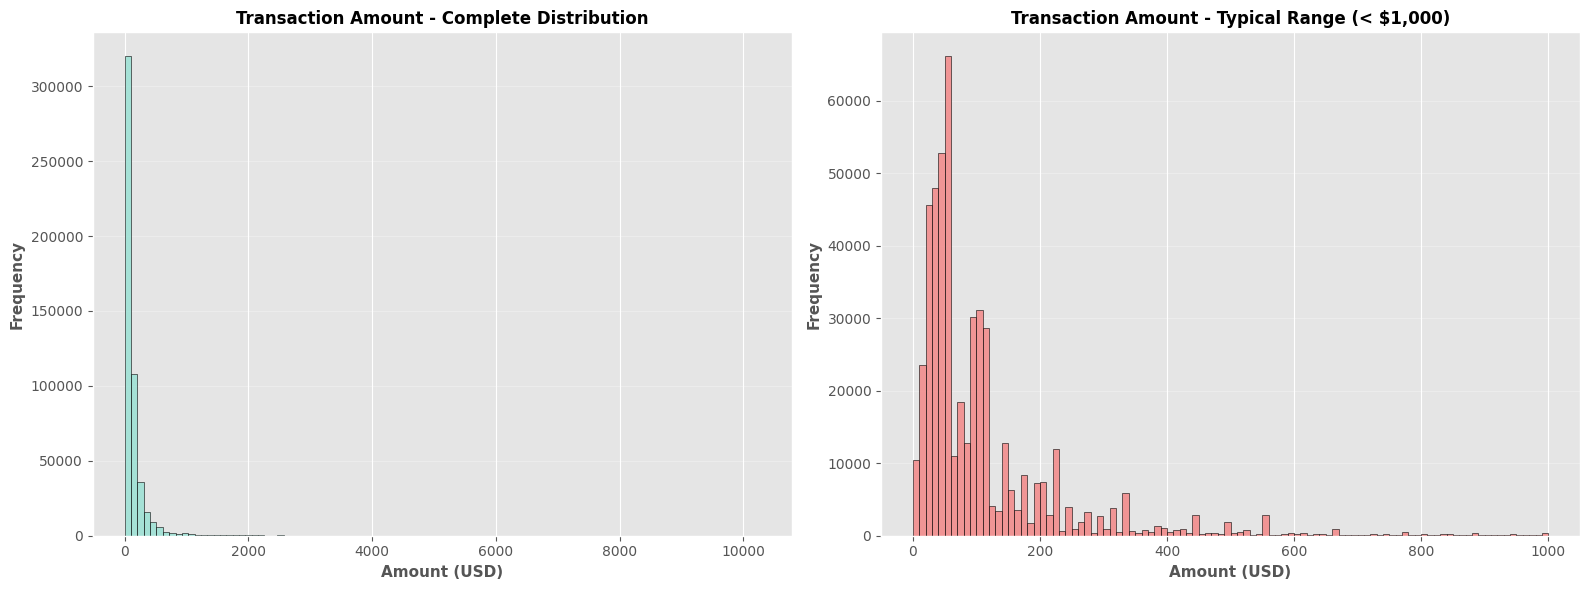

In [10]:
"""
Analyze transaction amount distribution with focus on typical range
"""
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Full distribution with all outliers
axes[0].hist(df['TransactionAmt'], bins=100, edgecolor='black', color='#95E1D3', alpha=0.8)
axes[0].set_title('Transaction Amount - Complete Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Amount (USD)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[0].grid(alpha=0.3, axis='y')

# Distribution focusing on typical transactions (< $1000)
axes[1].hist(df['TransactionAmt'][df['TransactionAmt'] < 1000], bins=100, edgecolor='black', color='#F38181', alpha=0.8)
axes[1].set_title('Transaction Amount - Typical Range (< $1,000)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Amount (USD)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### Temporal Analysis
Examining transaction patterns across time to reveal temporal trends and seasonal variations.

In [11]:
"""
Compile comprehensive dataset statistics and quality metrics
"""
numeric_cols_final = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols_final = df.select_dtypes(include=['object']).columns.tolist()

summary_stats = {
    'Total Records': f"{len(df):,}",
    'Total Features': len(df.columns),
    'Numerical Features': len(numeric_cols_final),
    'Categorical Features': len(categorical_cols_final),
    'Memory Usage (MB)': round(df.memory_usage(deep=True).sum() / 1024**2, 2),
    'Total Missing Values': f"{df.isnull().sum().sum():,}",
    'Missing Data %': round((df.isnull().sum().sum() / (len(df) * len(df.columns)) * 100), 2),
    'Features with Missing Data': (df.isnull().sum() > 0).sum(),
    'TransactionAmt Min': f"${df['TransactionAmt'].min():.2f}",
    'TransactionAmt Max': f"${df['TransactionAmt'].max():.2f}",
    'TransactionAmt Mean': f"${df['TransactionAmt'].mean():.2f}",
    'TransactionAmt Median': f"${df['TransactionAmt'].median():.2f}",
    'TransactionAmt Std Dev': f"${df['TransactionAmt'].std():.2f}",
}

summary_series = pd.Series(summary_stats)
display(summary_series)

Total Records                    506,691
Total Features                       434
Numerical Features                   403
Categorical Features                  31
Memory Usage (MB)                 2217.9
Total Missing Values          90,186,908
Missing Data %                     41.01
Features with Missing Data           385
TransactionAmt Min                 $0.02
TransactionAmt Max             $10270.00
TransactionAmt Mean              $134.73
TransactionAmt Median             $67.95
TransactionAmt Std Dev           $245.78
dtype: object

## Feature Relationships & Correlations

Exploring interdependencies among features to identify collinearity and multivariate relationships.

### Correlation Matrix Analysis
Quantifying linear relationships between numeric features to guide feature selection and engineering.

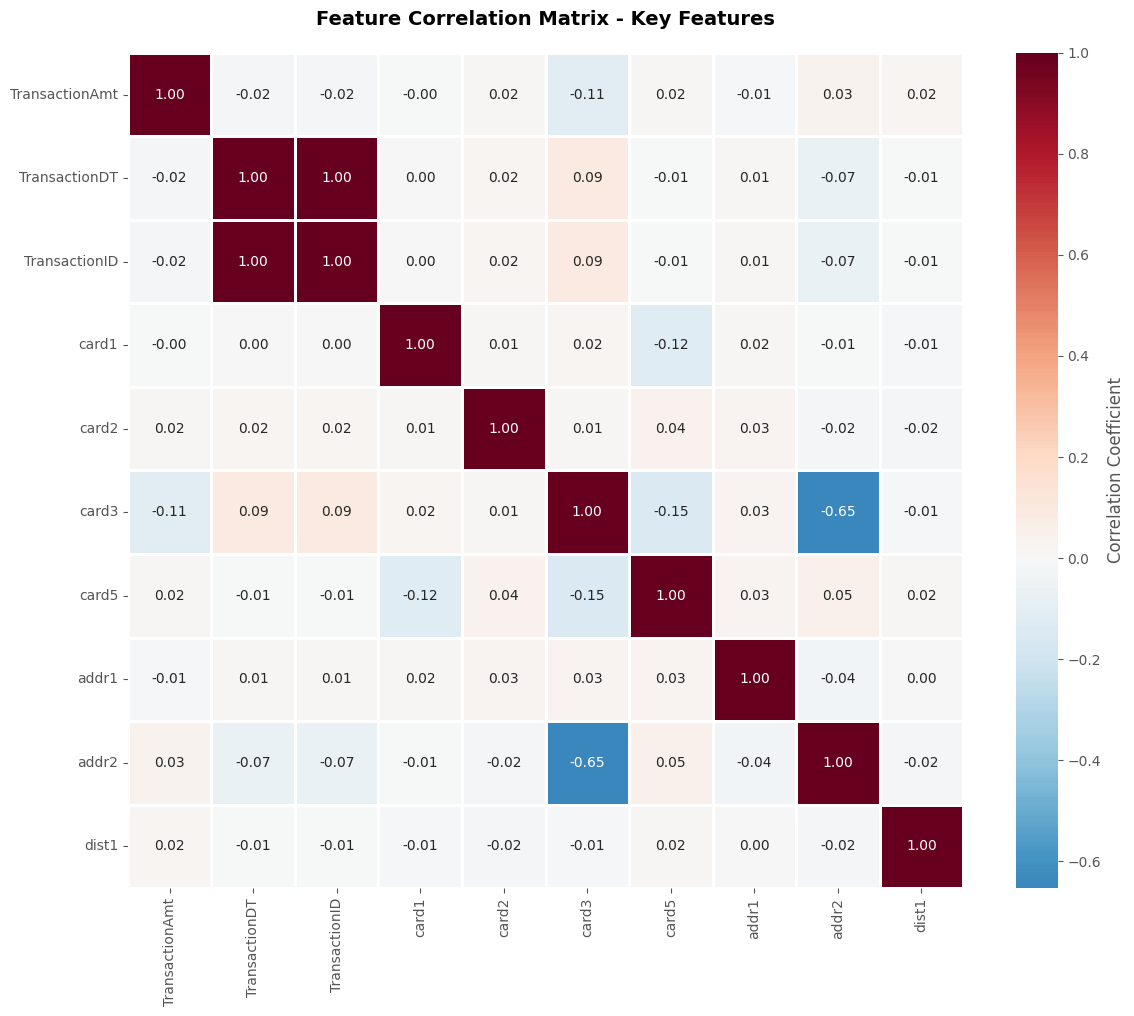

In [12]:
"""
Generate correlation heatmap for key numerical features
"""
numeric_df = df.select_dtypes(include=['int64', 'float64']).dropna(axis=1, how='all')

# Select key numeric features for correlation analysis
key_numeric = ['TransactionAmt', 'TransactionDT']
additional_cols = [col for col in numeric_df.columns if col not in key_numeric and not col.startswith('V')][:8]
cols_to_plot = key_numeric + additional_cols

if len(cols_to_plot) > 0:
    subset_corr = numeric_df[cols_to_plot].corr()
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(subset_corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, 
                cbar_kws={'label': 'Correlation Coefficient'}, square=True, linewidths=1)
    plt.title('Feature Correlation Matrix - Key Features', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()
else:
    print("Insufficient numeric features for correlation analysis")

In [13]:
"""
Extract and display strongest feature correlations
"""
corr_matrix = numeric_df.corr()

# Identify meaningful correlations (|r| > 0.1)
corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_value = corr_matrix.iloc[i, j]
        if abs(corr_value) > 0.1:
            corr_pairs.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlation': round(corr_value, 4)
            })

if corr_pairs:
    corr_df = pd.DataFrame(corr_pairs)
    corr_df_sorted = corr_df.iloc[corr_df['Correlation'].abs().argsort()[::-1]]
    display(corr_df_sorted.head(20))
else:
    print("No significant correlations found (threshold: |r| > 0.1)")

,Feature 1,Feature 2,Correlation
2324,V1,V88,1.0000
129,TransactionDT,TransactionDT_hours,1.0000
14642,V266,V269,0.9984
3529,V27,V28,0.9980
64,TransactionID,TransactionDT_hours,0.9978
0,TransactionID,TransactionDT,0.9978
12187,V190,V199,0.9971
433,C1,C2,0.9969
441,C1,C11,0.9961
13049,V211,V213,0.9958


### Detailed Categorical Distributions
Analyzing the cardinality and frequency distributions of categorical features.

In [14]:
"""
Display categorical feature distributions
"""
if 'ProductCD' in df.columns:
    cat_dist = df['ProductCD'].value_counts()
    cat_dist_title = 'Product Code Distribution'
elif 'card4' in df.columns:
    cat_dist = df['card4'].value_counts().head(15)
    cat_dist_title = 'Card Type Distribution (Top 15)'
else:
    cat_dist = df['DeviceType'].value_counts()
    cat_dist_title = 'Device Type Distribution'

distribution_df = pd.DataFrame({
    'Category': cat_dist.index,
    'Count': cat_dist.values,
    'Percentage': (cat_dist.values / cat_dist.sum() * 100).round(2)
})

display(distribution_df)

,Category,Count,Percentage
0,W,360987,71.24
1,C,69266,13.67
2,R,35647,7.04
3,H,29373,5.80
4,S,11418,2.25


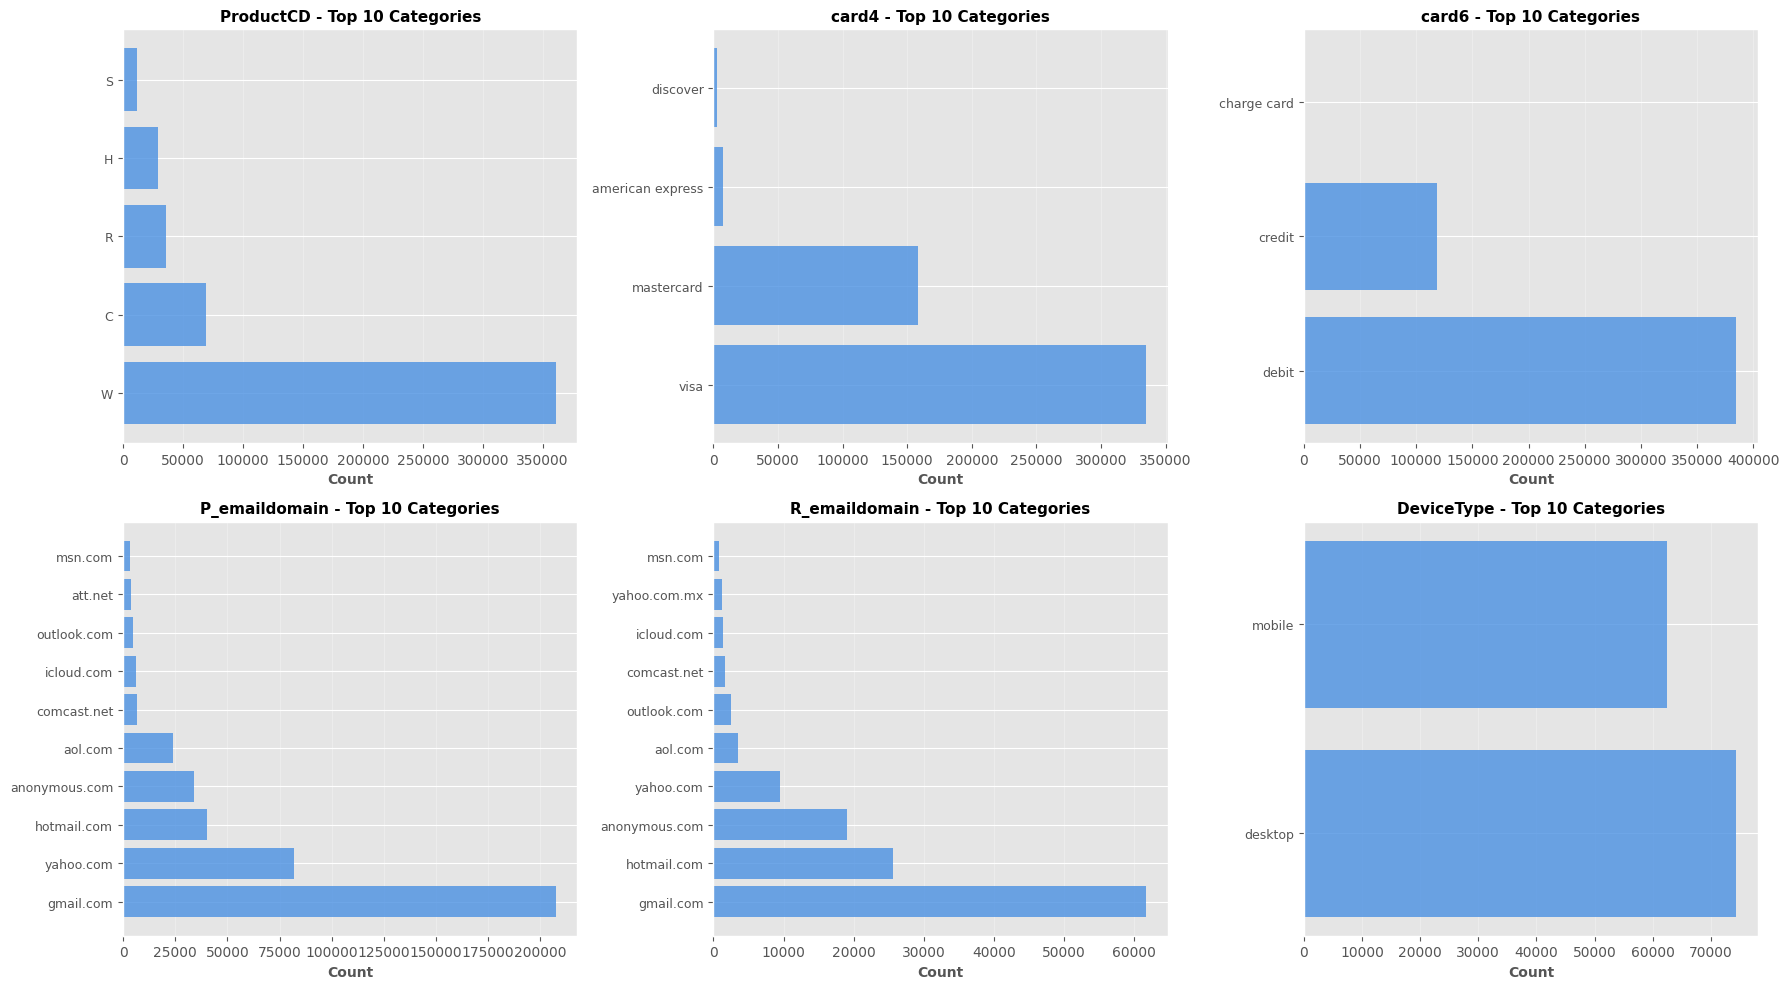

In [15]:
"""
Visualize distribution of key categorical features - top 10 values
"""
key_cats = ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'DeviceType']
existing_cats = [col for col in key_cats if col in df.columns]

if existing_cats:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    for idx, col in enumerate(existing_cats[:6]):
        if idx < len(existing_cats):
            top_values = df[col].value_counts().head(10)
            axes[idx].barh(range(len(top_values)), top_values.values, color='#4A90E2', alpha=0.8)
            axes[idx].set_yticks(range(len(top_values)))
            axes[idx].set_yticklabels(top_values.index.astype(str), fontsize=9)
            axes[idx].set_title(f'{col} - Top 10 Categories', fontsize=11, fontweight='bold')
            axes[idx].set_xlabel('Count', fontsize=10, fontweight='bold')
            axes[idx].grid(alpha=0.3, axis='x')
        else:
            axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print("No categorical features available for visualization")

### Categorical Distributions Visualization
Visual representation of categorical feature distributions for intuitive pattern recognition.

In [16]:
"""
Generate summary statistics for all categorical features
"""
categorical_cols_all = df.select_dtypes(include=['object']).columns.tolist()

if categorical_cols_all:
    cat_summary = pd.DataFrame({
        'Feature': categorical_cols_all,
        'Unique Values': [df[col].nunique() for col in categorical_cols_all],
        'Missing Count': [df[col].isna().sum() for col in categorical_cols_all],
        'Most Frequent Value': [df[col].value_counts().index[0] if df[col].value_counts().shape[0] > 0 else 'N/A' 
                                for col in categorical_cols_all]
    })
    
    cat_summary = cat_summary.sort_values('Unique Values', ascending=False)
    display(cat_summary)
else:
    print("No categorical features found in dataset")

,Feature,Unique Values,Missing Count,Most Frequent Value
30,DeviceInfo,2226,391634,Windows
23,id-33,390,436020,1920x1080
22,id-31,135,370066,chrome 70.0
21,id-30,86,436032,Windows 10
3,P_emaildomain,60,69192,gmail.com
4,R_emaildomain,60,370821,gmail.com
0,ProductCD,5,0,W
1,card4,4,3086,visa
2,card6,3,3007,debit
17,id-23,3,501629,IP_PROXY:TRANSPARENT


## Key Findings & Recommendations

### Data Quality Summary
- **Missing Data**: Significant missing values identified in identity-related features
- **Feature Types**: Mix of numerical transaction metrics and categorical identifiers
- **Dataset Size**: Comprehensive sample enabling robust pattern detection

### Notable Patterns
- **Transaction Amounts**: Right-skewed distribution with occasional high-value transactions
- **Temporal Distribution**: Transactions spread across reference timeline with identifiable patterns
- **Categorical Features**: Multiple categorical dimensions for user segmentation and behavior analysis